## E-Commerce Sales Analytics Project

Created by: Urvesh Dabhi

Tools Used: Python, Pandas, Matplotlib, Seaborn ,SQL,mySQL

Dataset: Sample Superstore Dataset (kaggle) 


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_excel("Sample - Superstore.xls")

In [4]:
df.shape

(9994, 21)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [30]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

11 null values found in Postal Code column, all belonging to Burlington city. Since Postal Code is not used in any analysis, these rows are retained.

In [33]:
df.duplicated().sum()

np.int64(0)

Data Cleaning Summary

- Dataset contains 9,994 records and 21 columns.
- 11 missing values found in Postal Code.
- All missing values belong to Burlington, Vermont.
- No duplicate records found.
- Date columns already in datetime format.

In [6]:
df['Order_Year'] = df['Order Date'].dt.year

In [8]:
df['Order_Month'] = df['Order Date'].dt.month_name()

In [10]:
# number of shipping days 
df['Shipping_Days'] = ( df['Ship Date'] - df['Order Date']).dt.days

In [4]:
returns_df = pd.read_excel('Sample - Superstore.xls',sheet_name='Returns')

In [5]:
people_df = pd.read_excel('Sample - Superstore.xls',sheet_name='People')

## Data Preparation

The Superstore dataset consists of Orders, Returns, and People sheets.

Orders sheet was used for sales, profit, customer, and shipping analysis.

Returns sheet was used to calculate return rates and investigate returned orders.

In [56]:
# Total Sales 
df['Sales'].sum()

np.float64(2297200.8603)

In [63]:
# Total Profit 
df['Profit'].sum()

np.float64(286397.0216999999)

In [62]:
# Total Sales by Category 
df.groupby(['Category'])['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [64]:
# Total Profit by Category 
df.groupby(['Category'])['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [65]:
# Sales by Region 
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [66]:
# Profit by region 
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [68]:
# sales by subcategory 
df.groupby(['Sub-Category'])['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [69]:
# profit by subcategory 
df.groupby(['Sub-Category'])['Profit'].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [70]:
# Top 10 products by sales
df.groupby(['Product Name'])['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [73]:
# Top 10 products by profit
df.groupby(['Product Name'])['Profit'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

### Category and Regional Insights

- Technology generated the highest revenue and profit.
- West region generated the highest sales.
- Consumer segment contributed the highest profit.
- Standard Class was the most commonly used shipping mode.

In [44]:
df['Shipping_Days'].mean()

np.float64(3.9582749649789872)

In [45]:
df.groupby('Ship Mode')['Shipping_Days'].mean()

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006702
Name: Shipping_Days, dtype: float64

### Shipping Analysis

- Same Day is the fastest shipping mode.
- Average delivery time across all orders is approximately 4 days.
- Standard Class takes around 5 days on average.

In [36]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
      .reset_index()
)

monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

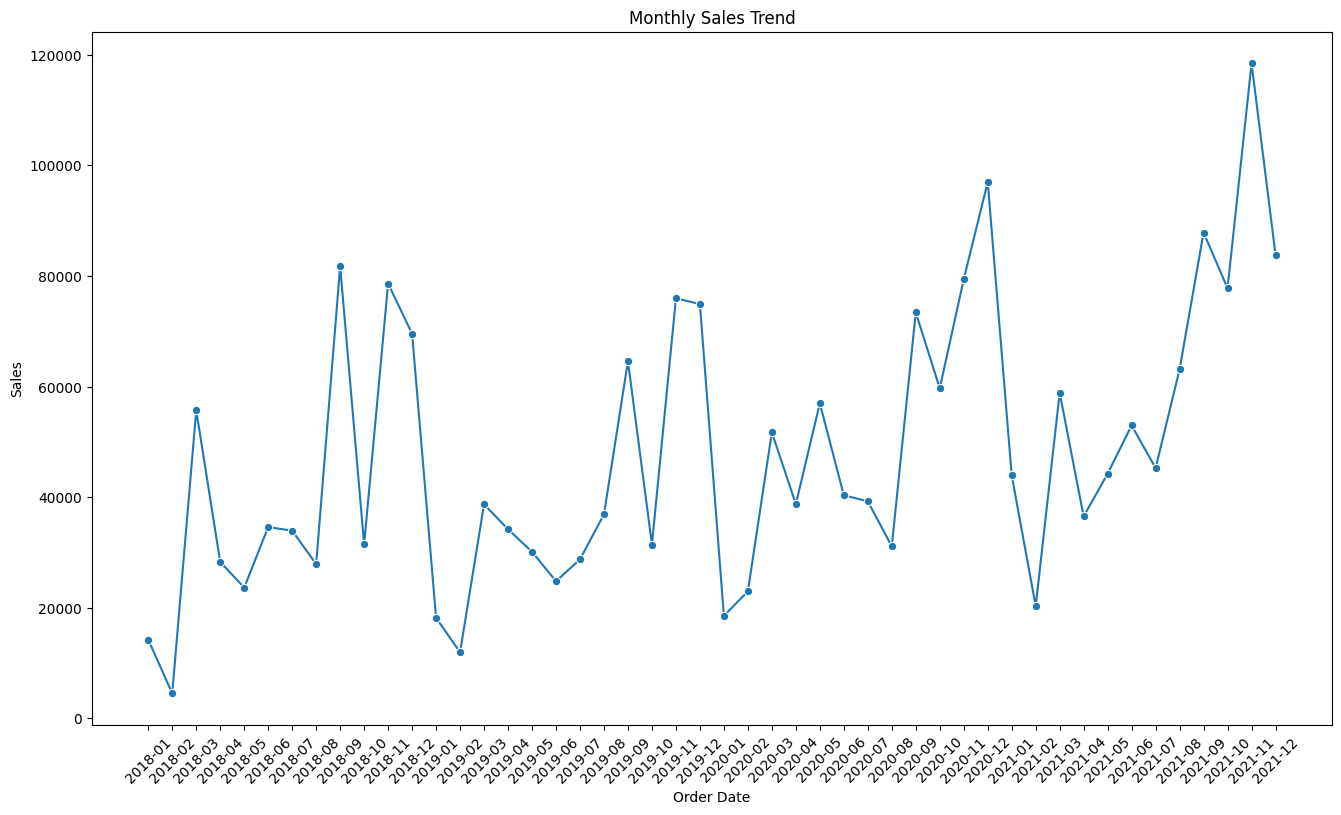

In [43]:
plt.figure(figsize=(16,9))
sns.lineplot(x='Order Date',y='Sales', data=monthly_sales,marker = 'o')

plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()

Monthly sales show a generally upward trend from 2018 to 2021, with the highest sales recorded in November 2021 (~118K). Sales spikes are commonly observed during the final quarter of each year, indicating strong seasonal demand.

## Return Analysis Limitation

Return analysis was performed at the order level because the Returns dataset identifies returned orders using Order ID but does not specify which individual products within an order were returned.

As a result, category-wise return rates should be interpreted as indicative rather than exact product-level return rates.

## Key Insights

- Technology emerged as the leading category in both revenue and profitability.
- West region recorded the highest return rate (~11.7%), significantly higher than other regions.
- Consumer customers contributed the largest share of profit.
- Standard Class was the most frequently used shipping mode.
- Same Day shipping was the fastest option.
- Average delivery time was approximately 4 days.
- Sales increased significantly between 2018 and 2021.
- November 2021 recorded the highest monthly sales (~118K).

## Conclusion

This project analyzed 9,994 retail transactions from the E-Commerce Sales dataset using Python and SQL.

The analysis identified major sales drivers, profitable categories, customer behavior, shipping performance, and return patterns.

Technology emerged as the strongest category, West generated the highest sales but also had the highest return rate, and overall sales showed significant growth from 2018 to 2021.